In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-01-08 12:29:14--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-01-08 12:29:15 (7.33 MB/s) - ‘names.txt’ saved [228145/228145]



In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[:n2])

Streaming output truncated to the last 5000 lines.
.br ---> i
bri ---> a
ria ---> u
iau ---> n
aun ---> a
una ---> .
bran
... ---> b
..b ---> r
.br ---> a
bra ---> n
ran ---> .
reuel
... ---> r
..r ---> e
.re ---> u
reu ---> e
eue ---> l
uel ---> .
paisyn
... ---> p
..p ---> a
.pa ---> i
pai ---> s
ais ---> y
isy ---> n
syn ---> .
maudie
... ---> m
..m ---> a
.ma ---> u
mau ---> d
aud ---> i
udi ---> e
die ---> .
legion
... ---> l
..l ---> e
.le ---> g
leg ---> i
egi ---> o
gio ---> n
ion ---> .
yannick
... ---> y
..y ---> a
.ya ---> n
yan ---> n
ann ---> i
nni ---> c
nic ---> k
ick ---> .
daniel
... ---> d
..d ---> a
.da ---> n
dan ---> i
ani ---> e
nie ---> l
iel ---> .
faithmarie
... ---> f
..f ---> a
.fa ---> i
fai ---> t
ait ---> h
ith ---> m
thm ---> a
hma ---> r
mar ---> i
ari ---> e
rie ---> .
shine
... ---> s
..s ---> h
.sh ---> i
shi ---> n
hin ---> e
ine ---> .
roanan
... ---> r
..r ---> o
.ro ---> a
roa ---> n
oan ---> a
ana ---> n
nan ---> .
zeke
... ---> z
..z ---> e
.ze 

In [8]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [9]:
for _ in range(1000):
  ix = torch.randint(0, Xtr.shape[0], (32, ))
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  for p in parameters:
    p.grad = None
  loss.backward()
  for p in parameters:
    p.data += -0.1 * p.grad
print(loss.item())

4.266107559204102


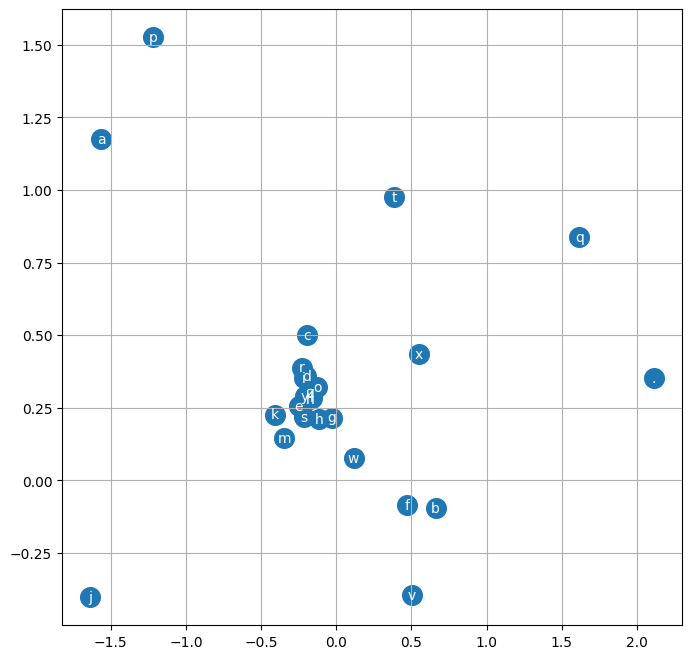

In [10]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [14]:
block_size =3

In [15]:
for _ in range(20):
  out = []
  context = [0] * block_size # Initialize context with block_size zeroes
  while True:
    emb = C[torch.tensor([context])]
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim = 1)
    ix = torch.multinomial(probs, num_samples=1).item() # Corrected num_sample to num_samples
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print("".join(itos[i] for i in out))

.
aakaufyaalcniaa.
daa.
nlbamwytaa.
.
.
dlaenaein.
stlbakaalone.
gniaatolbakinannnaitebakaalayokoea.
nezehaenenljnaje.
alienrenontaa.
rcaabsoandenc.
nnaatoolnaatyaginkeafvzraatqhzbecdlatoaatoaatopjrs.
rrnzjbaatoaylsaatoeaoaa.
avrarneynysoaatqh.
.
.
jn.
ojrr.
eelne.
